In [35]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
import statsmodels.formula.api as smf

# Parameters
desired_start_date_of_samples = datetime.strptime('1974-02-01', '%Y-%m-%d') # Earliest date for excess bond premium
HORIZON_IN_QUARTERS = 4
DATA_DIR = '/home/rproner/Documents/Data/'


In [36]:
# --- Load FRED monthly file and build indices ---
fred_y = pd.read_csv(os.path.join(DATA_DIR, '2025-08-FRED-MD.csv'))

fred_y['date'] = pd.date_range('1959-01-01', '2025-07-01', freq='MS')
fred_y.drop(columns=[c for c in ['sasdate'] if c in fred_y.columns], inplace=True, errors='ignore')
fred_y.set_index('date', inplace=True)

In [37]:
# Load nfci 
nfci = pd.read_csv(os.path.join(DATA_DIR, 'nfci_monthly.csv'), index_col=0, parse_dates=True)


## Vulnerable Growth Data

$$Q(\dot IP_{t:t+h}|t) = b_0 + b_1 NFCI_t + b_2 \dot IP_{t-3:t}$$

In [45]:
lagged_ip_growth = (np.log(fred_y['INDPRO']) - np.log(fred_y['INDPRO']).shift(12)).shift(3*HORIZON_IN_QUARTERS + 1) # We shift the features not the targets. so we need t-12 ip growth to predict t
lagged_1q_ip_growth = (np.log(fred_y['INDPRO']) - np.log(fred_y['INDPRO']).shift(3)).shift(3*HORIZON_IN_QUARTERS + 1)
lagged_nfci = nfci[['NFCI']].shift(3*HORIZON_IN_QUARTERS + 1) # Lag extra month because uses spreads from FRED

# Subset dates
last_date = datetime.strptime('2024-12-01', '%Y-%m-%d')
last_date_for_save = last_date.strftime('%Y-%m')
lagged_ip_growth= lagged_ip_growth.loc[desired_start_date_of_samples:last_date]
lagged_1q_ip_growth= lagged_1q_ip_growth.loc[desired_start_date_of_samples:last_date]
lagged_nfci = lagged_nfci.loc[desired_start_date_of_samples:last_date]

vg_X = pd.DataFrame({'NFCI': lagged_nfci.values.flatten(), 'lagged_IP_yoy': lagged_ip_growth.values.flatten(), 'lagged_IP_qoq': lagged_1q_ip_growth.values.flatten()}, index=lagged_nfci.index)
print(vg_X)

vg_X.to_csv(os.path.join(DATA_DIR, f'EconomyAtRisk/us_vulnerable_growth_predictors_{HORIZON_IN_QUARTERS}q_{last_date_for_save}.csv'))

                     NFCI  lagged_IP_yoy  lagged_IP_qoq
observation_date                                       
1974-02-01       -0.14570       0.092999       0.030193
1974-03-01        0.40402       0.097184       0.032692
1974-04-01        1.03411       0.090667       0.021922
1974-05-01        1.25854       0.079418       0.013320
1974-06-01        1.16061       0.085872       0.005600
...                   ...            ...            ...
2024-08-01       -0.23913       0.000211      -0.001473
2024-09-01       -0.29968      -0.000729       0.001108
2024-10-01       -0.34243      -0.002171       0.009016
2024-11-01       -0.30526      -0.008408      -0.004805
2024-12-01       -0.29318      -0.002126      -0.002023

[611 rows x 3 columns]


## Unemployment at Risk

$$
Q (\Delta_{12} u_{t+h}| t ) = b_0 + b_1 u_t \Delta_{12} PCE_t + b_3 \Delta_{48} log(BUSLOANS_t/INDPRO_t) + b_4(BAA_t-GS10_t) + b_5(GS10_t-FEDFUNDS_t)
$$

            UNRATE_lvl  PCE_gr_4q  BUSLOANS_to_IP_gr_16q  BAA_GS10  \
date                                                                 
1974-02-01         4.9   0.077926               0.190893      1.44   
1974-03-01         5.0   0.081650               0.210249      1.33   
1974-04-01         4.9   0.066817               0.237206      1.32   
1974-05-01         5.0   0.059965               0.237185      1.42   
1974-06-01         4.9   0.057080               0.231617      1.21   
...                ...        ...                    ...       ...   
2024-08-01         3.5   0.027314               0.150799      1.84   
2024-09-01         3.7   0.021811               0.151644      1.85   
2024-10-01         3.8   0.022519               0.144975      1.78   
2024-11-01         3.9   0.022914               0.147299      1.83   
2024-12-01         3.7   0.030150               0.147086      1.79   

            GS10_FEDFUNDS  
date                       
1974-02-01           0.52  
1974-

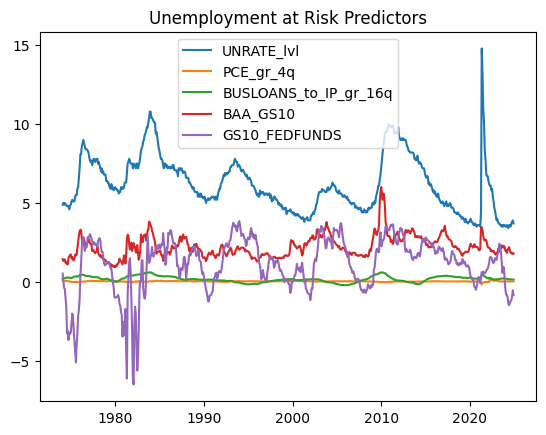

In [39]:
u_t = fred_y['UNRATE'].shift(3*HORIZON_IN_QUARTERS + 1)
pce_gr = (np.log(fred_y['DPCERA3M086SBEA']) - np.log(fred_y['DPCERA3M086SBEA']).shift(12)).shift(3*HORIZON_IN_QUARTERS + 1)
busloans_to_ip = (fred_y['BUSLOANS'] / fred_y['INDPRO'])
busloans_to_ip_gr = (np.log(busloans_to_ip) - np.log(busloans_to_ip).shift(48)).shift(3*HORIZON_IN_QUARTERS + 1)
baa_gs10 = (fred_y['BAA'] - fred_y['GS10']).shift(3*HORIZON_IN_QUARTERS + 1)
gs10_ff = (fred_y['GS10'] - fred_y['FEDFUNDS']).shift(3*HORIZON_IN_QUARTERS + 1)

# Subset dates
u_t = u_t.loc[desired_start_date_of_samples:last_date]
pce_gr = pce_gr.loc[desired_start_date_of_samples:last_date]
busloans_to_ip_gr = busloans_to_ip_gr.loc[desired_start_date_of_samples:last_date]
baa_gs10 = baa_gs10.loc[desired_start_date_of_samples:last_date]
gs10_ff = gs10_ff.loc[desired_start_date_of_samples:last_date]

ur_X = pd.DataFrame({'UNRATE_lvl': u_t.values.flatten(), 'PCE_gr_4q': pce_gr.values.flatten(), 'BUSLOANS_to_IP_gr_16q': busloans_to_ip_gr.values.flatten(), 'BAA_GS10': baa_gs10.values.flatten(), 'GS10_FEDFUNDS': gs10_ff.values.flatten()}, index=u_t.index)
print(ur_X)
plt.plot(ur_X)
plt.title('Unemployment at Risk Predictors')
plt.legend(ur_X.columns)
plt.show()

ur_X.to_csv(os.path.join(DATA_DIR, f'EconomyAtRisk/us_unemployment_at_risk_predictors_{HORIZON_IN_QUARTERS}q_{last_date_for_save}.csv'))

## Inflation at Risk

$$
\hat Q_{tau}(\pi_{t+h}| t) = \hat \mu_\tau + (1-\hat \lambda_\tau) \pi^*_{t-1} + \hat \lambda_\tau \pi_t^{LTE} +  \hat \theta (u_t - u_t^*) + \hat \gamma \pi^O_t + \hat \delta f_t
$$

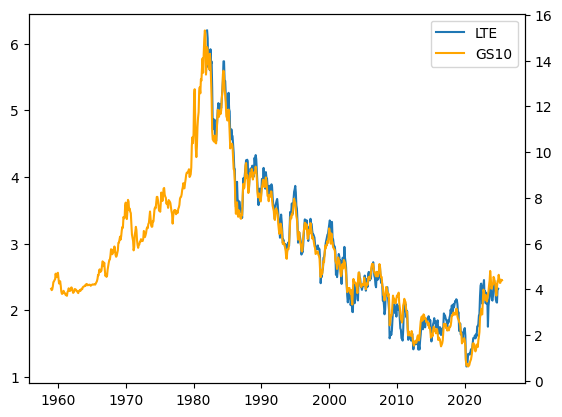

In [40]:
lte = pd.read_csv(os.path.join(DATA_DIR, 'EXPINF10YR.csv'), index_col=0, parse_dates=True)
gs10 = fred_y['GS10']

fig, ax = plt.subplots()
ax.plot(lte, label='LTE')

ax2 = ax.twinx()
ax2.plot(gs10, label='GS10', color='orange')
ax.legend()
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='best')
plt.show()

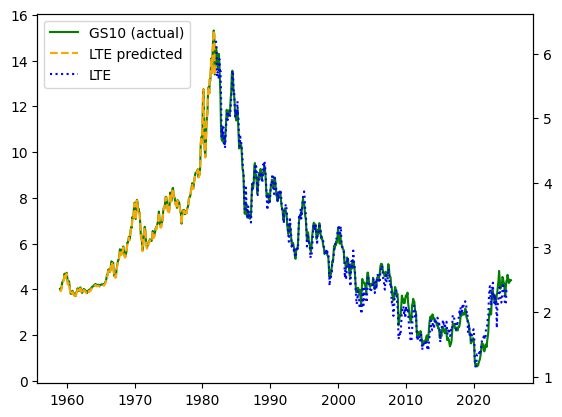

In [41]:
backcast_data = pd.concat([gs10, lte], axis=1).dropna()
backcast_predict = gs10.loc[:'1981-12-01']
backcast_predict_df = backcast_predict.to_frame(name='GS10')

backcast_model = smf.ols('EXPINF10YR ~ GS10', data=backcast_data).fit()
preds = backcast_model.predict(backcast_predict_df)

fig, ax = plt.subplots()
line1, = ax.plot(gs10, color='green', linestyle='-', label='GS10 (actual)')
ax2 = ax.twinx()
line2, = ax2.plot(preds, color='orange', linestyle='--', label='LTE predicted')
line3, = ax2.plot(lte, color='blue', linestyle=':', label='LTE')

# Collect handles and labels from both axes
lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left')

plt.show()

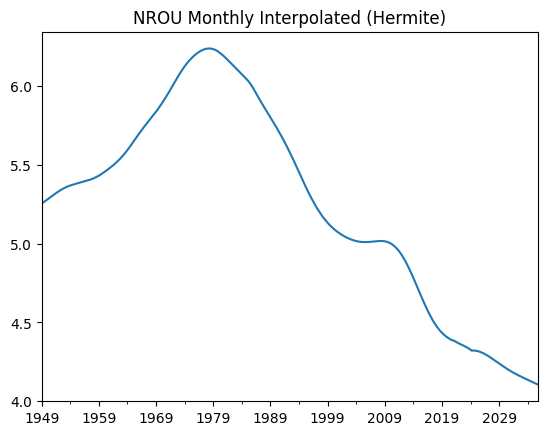

In [42]:
# Interpolate NROU from quarterly to monthly
nrou = pd.read_csv(os.path.join(DATA_DIR, 'NROU.csv'), index_col=0, parse_dates=True)

from scipy.interpolate import PchipInterpolator

# 1. Get quarterly dates as ordinal numbers
quarterly_dates = nrou.index.to_period('Q').to_timestamp()
quarterly_ord = quarterly_dates.map(pd.Timestamp.toordinal).values

# 2. Get monthly target dates
monthly_dates = pd.date_range(quarterly_dates.min(), quarterly_dates.max(), freq='MS')
monthly_ord = monthly_dates.map(pd.Timestamp.toordinal).values

# 3. Interpolate using Hermite (PCHIP)
hermite = PchipInterpolator(quarterly_ord, nrou.iloc[:,0].values)
monthly_nrou = pd.Series(hermite(monthly_ord), index=monthly_dates, name=nrou.columns[0])

# 4. Preview and save
monthly_nrou.plot(title='NROU Monthly Interpolated (Hermite)')

monthly_nrou.to_csv(os.path.join(DATA_DIR, 'NROU_monthly_hermite.csv'))

In [43]:
# Bond premium 
ebp = pd.read_csv(os.path.join(DATA_DIR, 'ebp_csv.csv'), index_col=0, parse_dates=True) # Starts 1973-01s

611 611 611 611 611


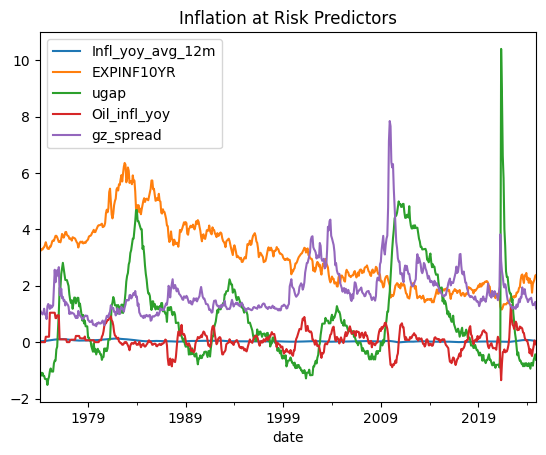

In [44]:
lagged_infl = (np.log(fred_y['CPIAUCSL']) - np.log(fred_y['CPIAUCSL']).shift(12)).shift(3*HORIZON_IN_QUARTERS + 1)
avg_yoy_infl_past_year = lagged_infl.rolling(window=12, min_periods=1).mean() # Already lagged 
lagged_lte_full = pd.concat([preds.to_frame(name='EXPINF10YR'), lte], axis=0).sort_index().shift(3*HORIZON_IN_QUARTERS + 1)
lagged_nrou = monthly_nrou.shift(3*HORIZON_IN_QUARTERS) # There is no announcement delay for NROU
ugap = u_t - lagged_nrou # unemployment gap, u_t from above
lagged_oil_infl = (np.log(fred_y['OILPRICEx']) - np.log(fred_y['OILPRICEx']).shift(12)).shift(3*HORIZON_IN_QUARTERS + 1)
lagged_credit_spread = ebp[['gz_spread']].shift(3*HORIZON_IN_QUARTERS + 1)
# print(lagged_credit_spread.dropna())

# Subset dates
avg_yoy_infl_past_year = avg_yoy_infl_past_year.loc[desired_start_date_of_samples:last_date]
lagged_lte_full = lagged_lte_full.loc[desired_start_date_of_samples:last_date]
ugap = ugap.loc[desired_start_date_of_samples:last_date]
lagged_oil_infl = lagged_oil_infl.loc[desired_start_date_of_samples:last_date]
lagged_credit_spread = lagged_credit_spread.loc[desired_start_date_of_samples:last_date]

# print the length of each series to ensure they match
print(len(avg_yoy_infl_past_year), len(lagged_lte_full), len(ugap), len(lagged_oil_infl), len(lagged_credit_spread))
ir_X = pd.DataFrame({'Infl_yoy_avg_12m': avg_yoy_infl_past_year.values.flatten(), 'EXPINF10YR': lagged_lte_full.values.flatten(), 'ugap': ugap.values.flatten(), 'Oil_infl_yoy': lagged_oil_infl.values.flatten(), 'gz_spread': lagged_credit_spread.values.flatten()}, index=avg_yoy_infl_past_year.index)

ir_X.plot()
plt.title('Inflation at Risk Predictors')
plt.legend(ir_X.columns)
plt.show()


ir_X.to_csv(os.path.join(DATA_DIR, f'EconomyAtRisk/us_inflation_at_risk_predictors_{HORIZON_IN_QUARTERS}q_{last_date_for_save}.csv'))